In [2]:
# draw the velocity plot
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='same')

def gait_define(current_data, threshold_level, use_savgol=True):
    current_data = np.array(current_data)

    velocity = np.diff(current_data[:, 0], axis=0)
    # add running average or smoothing function to reduce the noises 

    # 平滑速度
    vel_smooth = moving_average(velocity, w=5)  

    # 阈值
    vel_max = np.max(vel_smooth)
    vel_thresh = threshold_level if threshold_level > 1 else vel_max * threshold_level

    swing_all = np.where(vel_smooth > vel_thresh)[0]

    diffs = np.diff(swing_all, prepend=-999)
    boundaries = np.where(diffs != 1)[0]
    swing_start = swing_all[boundaries[:-1]]
    swing_end = swing_all[boundaries[1:] - 1]

    # 删除周期太短的
    valid = (swing_end - swing_start) >= 3
    swing_start = swing_start[valid]
    swing_end = swing_end[valid]

    plt.figure(figsize=(12, 6))
    plt.plot(vel_smooth, label='Smoothed Velocity X')
    plt.plot(current_data[1:, 2], label='Z position')
    plt.plot(swing_start, vel_smooth[swing_start], '*r', label='Swing Start')
    plt.plot(swing_end, vel_smooth[swing_end], 'or', label='Swing End')
    plt.xlabel('Frames')
    plt.ylabel('Speed or Position')
    plt.legend()
    plt.show()

    m = current_data.shape[0]
    if len(swing_start) < 1:
        swing_start = np.array([0, m - 2])
        swing_end = np.array([m - 4])
    if len(swing_end) >= len(swing_start):
        swing_end = swing_end[:-1]

    return swing_start, swing_end


In [3]:
# draw the acceleration

# def moving_average(x, w=5):
#     return np.convolve(x, np.ones(w)/w, mode='same')

import pandas as pd

def moving_average_pandas(x, w=5):
    return pd.Series(x).rolling(w, center=True, min_periods=1).mean().to_numpy()

def gait_ac(current_data):
    current_data = np.array(current_data)

    postion = current_data[:, 0]
    position_smooth = moving_average_pandas(postion, w=2)
    velocity = np.diff(current_data[:, 0], axis=0)
    acceleration = np.diff(velocity)


    # add running average or smoothing function to reduce the noises 

    #平滑
    vel_smooth = moving_average(velocity, w=5)  

    # # 阈值
    # vel_max = np.max(vel_smooth)
    # vel_thresh = threshold_level if threshold_level > 1 else vel_max * threshold_level

    # swing_all = np.where(vel_smooth > vel_thresh)[0]

    # diffs = np.diff(swing_all, prepend=-999)
    # boundaries = np.where(diffs != 1)[0]
    # swing_start = swing_all[boundaries[:-1]]
    # swing_end = swing_all[boundaries[1:] - 1]

    # # 删除周期太短的
    # valid = (swing_end - swing_start) >= 3
    # swing_start = swing_start[valid]
    # swing_end = swing_end[valid]

    # calculate z-position related values
    z_postion = current_data[:, 2]
    z_position_smooth = moving_average_pandas(z_postion, w=2)
    z_velocity = np.diff(current_data[:, 2], axis=0)
    z_vel_smooth = moving_average(z_velocity, w=5)    
    z_acceleration = np.diff(z_velocity)

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(position_smooth, label='Smoothed X position')
    axs[0].set_ylabel("smoothed X position")
    axs[0].legend()
    axs[0].set_xlim(0, 200)

    axs[1].plot(velocity, label='Velocity X')
    axs[1].plot(acceleration, label='Acceleration X')
    # axs[1].plot(swing_start, vel_smooth[swing_start], '*r', label='Swing Start')
    # axs[1].plot(swing_end, vel_smooth[swing_end], 'or', label='Swing End')
    axs[1].set_xlabel("Frames")
    axs[1].set_ylabel("Speed  / Acceleration")
    axs[1].axhline(0, color='grey', linewidth=1, linestyle='-')
    axs[1].legend()
    axs[1].set_xlim(0, 200)

    axs[2].plot(z_postion, label='Smoothed Z position')
    axs[2].plot(z_velocity, label='Velocity Z')
    axs[2].plot(z_acceleration, label='Acceleration Z')
    axs[2].set_xlabel("Frames")
    axs[2].set_ylabel("Height / Speed / Acceleration")
    axs[2].axhline(0, color='grey', linewidth=1, linestyle='-')
    axs[2].legend()
    axs[2].set_xlim(0, 200) 

plt.tight_layout()
plt.show()


    # m = current_data.shape[0]
    # if len(swing_start) < 1:
    #     swing_start = np.array([0, m - 2])
    #     swing_end = np.array([m - 4])
    # if len(swing_end) >= len(swing_start):
    #     swing_end = swing_end[:-1]

    # return swing_start, swing_end




<Figure size 640x480 with 0 Axes>

In [4]:
# calculate the metrics at events
# define the events based on x-postion
 
import numpy as np
import pandas as pd

def gait_events(current_data):
    current_data = np.array(current_data)

    # Smooth positions
    x_position = current_data[:, 0]
    x_position_smooth = moving_average_pandas(x_position, w=2)
    x_velocity = np.diff(x_position_smooth, prepend=x_position_smooth[0])
    x_acceleration = np.diff(x_velocity, prepend=x_velocity[0])

    z_position = current_data[:, 2]
    z_position_smooth = moving_average_pandas(z_position, w=2)
    z_velocity = np.diff(z_position_smooth, prepend=z_position_smooth[0])
    z_acceleration = np.diff(z_velocity, prepend=z_velocity[0])

    # Define events
    swing_start_points = np.where((x_velocity[:-1] <= 0) & (x_velocity[1:] > 0))[0] + 1
    stance_start_points = np.where((x_velocity[:-1] > 0) & (x_velocity[1:] <= 0))[0] + 1

    # === Table 1: Swing events ===
    swing_data = []
    for i in swing_start_points:
        swing_data.append({
            'frame': i,
            'x_velocity': x_velocity[i],
            'x_acceleration': x_acceleration[i],
            'z_velocity': z_velocity[i],
            'z_acceleration': z_acceleration[i],
            'z_position': z_position[i],
        })
    swing_df = pd.DataFrame(swing_data)

    # === Table 2: Stance events ===
    stance_data = []
    for i in stance_start_points:
        stance_data.append({
            'frame': i,
            'x_velocity': x_velocity[i],
            'x_acceleration': x_acceleration[i],
            'z_velocity': z_velocity[i],
            'z_acceleration': z_acceleration[i],
            'z_position': z_position[i],
        })
    stance_df = pd.DataFrame(stance_data)

    return swing_df, stance_df


In [5]:
def gait_cycles(swing_df, stance_df):
    swing_frames = swing_df['frame'].values
    stance_frames = stance_df['frame'].values

    gait_cycles = []
    cycle_num = 1

    for swing_frame in swing_frames:
        # Find the next stance frame after this swing start
        future_stance = stance_frames[stance_frames > swing_frame]
        if len(future_stance) == 0:
            # No following stance → incomplete cycle
            gait_cycles.append({
                'gait_cycle_no': cycle_num,
                'swing_start_frame': swing_frame,
                'stance_start_frame': np.nan
            })
        else:
            stance_frame = future_stance[0]
            gait_cycles.append({
                'gait_cycle_no': cycle_num,
                'swing_start_frame': swing_frame,
                'stance_start_frame': stance_frame
            })
        cycle_num += 1

    gait_cycle_df = pd.DataFrame(gait_cycles)
    return gait_cycle_df


In [6]:
import os
os.chdir('/Users/ruitang/Documents/Vicon_analysis/data')

In [7]:
marker_list = {
        'R_Crest': 'SETUP 1:R_Crest',
        'R_Hip': 'SETUP 1:R_Hip',
        'R_Knee': 'SETUP 1:R_Knee',
        'R_Ankle': 'SETUP 1:R_Ankle',
        'R_Foot': 'SETUP 1:R_Foot',
        'R_Shoulder': 'SETUP 1:R_Shoulder',
        'R_Elbow': 'SETUP 1:R_Elbow',
        'R_Paw': 'SETUP 1:R_Paw',
        'L_Crest': 'SETUP 1:L_Crest',
        'L_Hip': 'SETUP 1:L_Hip',
        'L_Knee': 'SETUP 1:L_Knee',
        'L_Ankle': 'SETUP 1:L_Ankle',
        'L_Foot': 'SETUP 1:L_Foot',
        'L_Shoulder': 'SETUP 1:L_Shoulder',
        'L_Elbow': 'SETUP 1:L_Elbow',
        'L_Paw': 'SETUP 1:L_Paw'
    }

In [8]:
import os
import numpy as np
import pandas as pd

input_file = '10.csv'

speed = 10
framerate = 100

# === 1) Read marker names ===
marker_row = pd.read_csv(input_file, skiprows=2, nrows=1, header=None)
marker_names = marker_row.iloc[0, 2::3].dropna().tolist()

# === 2) Read numeric data ===
raw_df = pd.read_csv(input_file, skiprows=5, header=None)
num_df = raw_df.apply(pd.to_numeric, errors='coerce').dropna(axis=0)
data = num_df.values
if data.shape[0] == 0:
    print(f"⚠️ No valid data in {input_file}, skipping.")
    #return

# === 3) Frame & coordinates ===
frame_first = data[0, 0]
coords = data[:, 2:]

# === 4) X-direction compensation ===
t = np.arange(1, coords.shape[0] + 1)
coords[:, 0::3] += (speed / framerate) * t[:, None]
# coords[:, 0::3] shows all rows, and cols of 0, 3, 6, 9..., which means every x-axis position data.


In [9]:
# === 5) Extract marker_data ===
marker_data = {}
for key, name in marker_list.items():
    if name in marker_names:
        idx = marker_names.index(name)
        marker_data[key] = coords[:, 3*idx:3*idx+3]
# print available keys for debug
print("Available marker_data keys:", len(list(marker_data.keys())), list(marker_data.keys()))


Available marker_data keys: 16 ['R_Crest', 'R_Hip', 'R_Knee', 'R_Ankle', 'R_Foot', 'R_Shoulder', 'R_Elbow', 'R_Paw', 'L_Crest', 'L_Hip', 'L_Knee', 'L_Ankle', 'L_Foot', 'L_Shoulder', 'L_Elbow', 'L_Paw']


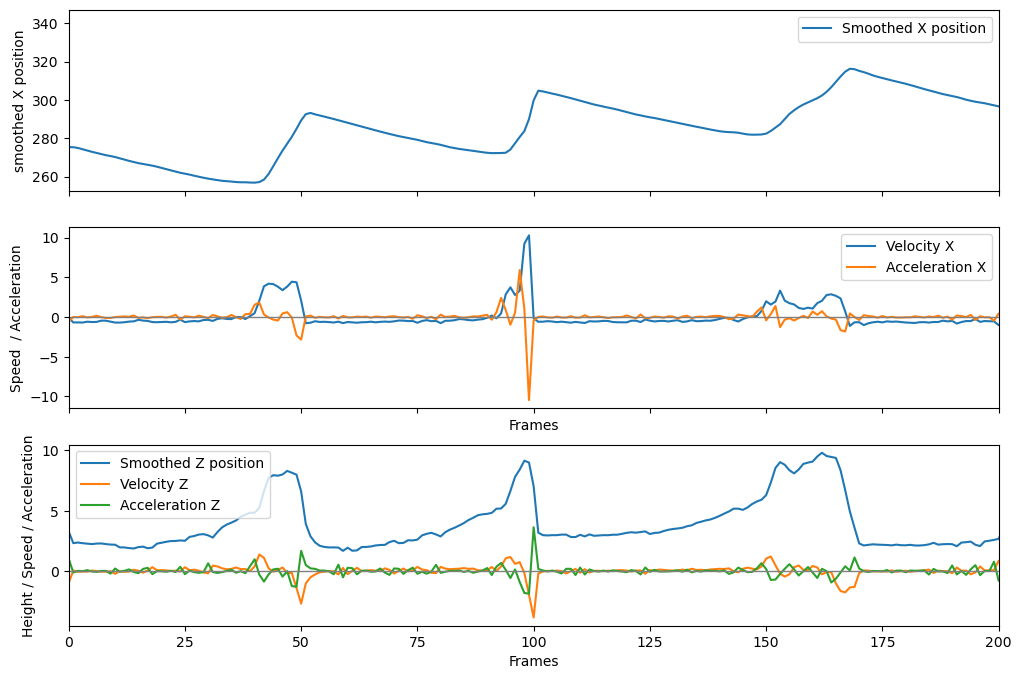

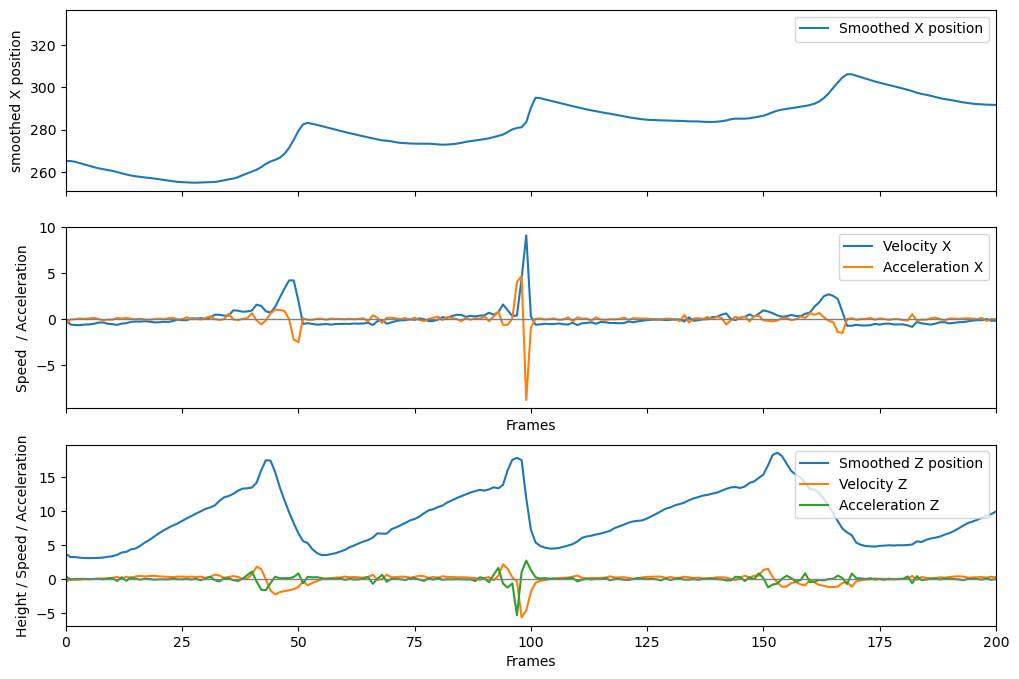

In [10]:
# NEW!!!Another try of gait define === 7) Gait events + append end-frame ===

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_file = 'vel_test_10.xlsx'

# === Settings ===
framerate = 100
output_path = Path(output_file)  # output_file is your .xlsx filename
excel_result_gait = output_path.parent / f"{output_path.stem}-gait.xlsx"
sheet_name = output_path.stem  # matches the MATLAB use of inputFileName(1:end-4)

events = {}
gait_data = {}
max_len = 0

# === Define limbs and parameters ===
limbs = [
    ('R_Hind', 'R_Foot'),
    ('R_Ankle', 'R_Ankle'),
]

# === Process gait for each limb ===
for tag, marker in limbs:
    gait_ac(marker_data[marker])
    

In [11]:
# gait events comparison

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_file = 'vel_test_10.xlsx'

# === Settings ===
framerate = 100
output_path = Path(output_file)  # output_file is your .xlsx filename
excel_result_gait = output_path.parent / f"{output_path.stem}-gait.xlsx"
sheet_name = output_path.stem  # matches the MATLAB use of inputFileName(1:end-4)

events = {}
gait_data = {}
max_len = 0

# === Define limbs and parameters ===
limbs = [
    ('R_Hind', 'R_Foot'),
]

# === Process gait for each limb ===
for tag, marker in limbs:
    swing_df, stance_df = gait_events(marker_data[marker])
    #print(swing_df, stance_df)
    gait_cycle_df = gait_cycles(swing_df, stance_df)
    print(gait_cycle_df)
    

    gait_cycle_no  swing_start_frame  stance_start_frame
0               1                 41                  53
1               2                 92                 102
2               3                148                 169
3               4                222                 236
4               5                282                 298
5               6                345                 359
6               7                396                 411
7               8                451                 467
8               9                468                 475
9              10                518                 532
10             11                606                 616
11             12                652                 672
12             13                702                 716


In [12]:
def extract_kinematics_around_events(current_data, swing_start, stance_start, window=2):
    # current_data: shape [n_frames, 3], columns: x, z, (optional) time
    # compute velocity and acceleration
    x = current_data[:, 0]
    z = current_data[:, 2]

    vel_x = np.gradient(x)
    acc_x = np.gradient(vel_x)

    vel_z = np.gradient(z)
    acc_z = np.gradient(vel_z)

    def get_stats(events):
        stats = []
        for e in events:
            idx_start = max(0, e - window)
            idx_end = min(len(x), e + window + 1)
            stats.append([
                x[e], vel_x[e], acc_x[e],
                z[e], vel_z[e], acc_z[e]
            ])
        return np.array(stats)

    swing_stats = get_stats(swing_start)
    stance_stats = get_stats(stance_start)

    return swing_stats, stance_stats

In [13]:
def check_10_point_table(stats, event_type):
    # stats: N x 6 matrix for swing or stance
    # event_type: 'swing' or 'stance'
    checks = []

    for row in stats:
        x_pos, x_vel, x_acc, z_pos, z_vel, z_acc = row

        if event_type == 'stance':
            match = [
                True,  # local max — not checked numerically here
                x_vel > 0 and abs(x_vel) < 1,
                x_acc < 0,
                abs(z_pos - min(stats[:, 3])) < 1.0,  # close to min
                z_vel < 0,
                z_acc > 0
            ]
        elif event_type == 'swing':
            match = [
                True,  # local min
                x_vel > 0 and abs(x_vel) < 1,
                abs(x_acc - max(stats[:, 2])) < 1.0,  # local max
                z_pos < 7.0,
                z_vel > 0,
                z_acc > 0
            ]
        checks.append(match)

    return np.array(checks)

In [ ]:

swing_stats, stance_stats = extract_kinematics_around_events(marker_data['R_Foot'], swing_start, stance_start)
swing_check = check_10_point_table(swing_stats, 'swing')
stance_check = check_10_point_table(stance_stats, 'stance')

print("✅ Swing Event Matches:")
print(np.mean(swing_check, axis=0))  # proportion matching each criterion

print("✅ Stance Event Matches:")
print(np.mean(stance_check, axis=0))

NameError: name 'current_data' is not defined